In [26]:
def de_bruijn_ize(st,k):
    """
    Return De Bruijn Graph for a given sequencing read
    by creating the nodes from distinct k-1 mer and drawing
    the edges between the node (one edge per kmer)
    :param st: String of sequencing reads
    :param k: Assumed Kmer of the given string
    """
    edges = []
    nodes = set()

    for i in range(len(st) - k + 1):            # Iterate through every kmer in a string
        edges.append((st[i:i+k-1], st[i+1:i+k]))    # Represent an edge as a tuple of left and right k -1 mer
        
        # Add distinct k-1 mer to the node set for each kmer
        nodes.add(st[i:i+k-1])
        nodes.add(st[i+1:i+k])
    return nodes, edges 


In [27]:
def visualize_de_bruijn(st,k):
    """ Visualize a directed multigraph"""
    nodes, edges = de_bruijn_ize(st,k)
    dot_str = 'digraph "De Bruijn graph" {\n'
    for node in nodes:
        dot_str += ' %s [label="%s"] ; \n' % (node, node)

    for src, dst in edges:
        dot_str += ' %s -> %s  ; \n' % (src, dst)
    return dot_str + '}\n'


# Setup
Short: ensure the working Graphviz `dot` binary is available in the kernel PATH for rendering.

In [ ]:
import os, shutil
# Ensure the working Graphviz binary is available in the kernel (stable choice)
work_bin = r"C:\Users\xx\Your\Path\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\graphviz\bin"
os.environ['PATH'] = work_bin + os.pathsep + os.environ.get('PATH','')
from graphviz import Source
print('dot ->', shutil.which('dot'))


dot -> C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\graphviz\bin\dot.EXE


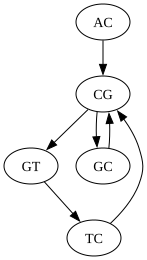

In [30]:
Source(visualize_de_bruijn('ACGCGTCG',3))
